# XYW-Net: Bio-Inspired Edge Detection with X, Y, and W Cells

**Bio-Inspired Deep Learning Model**

Paper: "Parallel pathways with X, Y, and W cells"

This notebook:
- Uses XYW-Net from workspace (already trained)
- Tests on HED_Small dataset
- Computes ODS/OIS/AP metrics
- Visualizes results

**Bio-Inspiration**: Parallel retinal pathways (X, Y, W cells) for feature integration

In [11]:
# ===== Configuration =====
from pathlib import Path
import sys

PROJECT_ROOT = Path('..')
DATASET_ROOT = PROJECT_ROOT / 'datasets' / 'HED_Small'
MODELS_DIR = PROJECT_ROOT / 'models'
OUTPUT_DIR = PROJECT_ROOT / 'bio DL' / 'outputs' / 'XYW-Net'

DEVICE = 'cuda'
BATCH_SIZE = 1
NUM_TEST_IMAGES = 20  # Set to None for all test images

In [12]:
# ===== Installs and Imports =====
import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch', 'torchvision', 'opencv-python', 'matplotlib', 'numpy', 'pillow', 'tqdm', 'scikit-learn'], check=False)

import os
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import average_precision_score

# Add parent directory to path to import xywnet
sys.path.insert(0, str(PROJECT_ROOT))

# Create directories
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device(DEVICE if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## Import XYW-Net Model

XYW-Net implements three parallel pathways inspired by retinal X, Y, and W cells:
- **X cells**: High spatial resolution (parvocellular pathway)
- **Y cells**: Motion sensitivity (magnocellular pathway)
- **W cells**: Wide receptive fields (koniocellular pathway)

In [13]:
# ===== Import XYW-Net from workspace =====
try:
    from xywnet import XYWNet
    print("✓ Imported XYW-Net from workspace")
except Exception as e:
    print(f"Could not import XYW-Net: {e}")
    print("Implementing simplified version...")
    
    # Simplified XYW-Net architecture
    class XYWNet(nn.Module):
        """Simplified XYW-Net with parallel pathways"""
        
        def __init__(self):
            super(XYWNet, self).__init__()
            
            # X pathway (high resolution, fine details)
            self.x_conv1 = nn.Conv2d(3, 64, 3, padding=1)
            self.x_conv2 = nn.Conv2d(64, 128, 3, padding=1)
            
            # Y pathway (motion, transient)
            self.y_conv1 = nn.Conv2d(3, 64, 5, padding=2)  # Larger receptive field
            self.y_conv2 = nn.Conv2d(64, 128, 5, padding=2)
            
            # W pathway (wide field, context)
            self.w_conv1 = nn.Conv2d(3, 64, 7, padding=3)  # Even larger
            self.w_conv2 = nn.Conv2d(64, 128, 7, padding=3)
            
            # Integration layers
            self.fusion = nn.Conv2d(384, 256, 1)  # 3 pathways * 128
            self.edge_out = nn.Conv2d(256, 1, 1)
            
        def forward(self, x):
            # X pathway
            x_feat = F.relu(self.x_conv1(x))
            x_feat = F.relu(self.x_conv2(x_feat))
            
            # Y pathway
            y_feat = F.relu(self.y_conv1(x))
            y_feat = F.relu(self.y_conv2(y_feat))
            
            # W pathway
            w_feat = F.relu(self.w_conv1(x))
            w_feat = F.relu(self.w_conv2(w_feat))
            
            # Fusion
            combined = torch.cat([x_feat, y_feat, w_feat], dim=1)
            fused = F.relu(self.fusion(combined))
            edge = self.edge_out(fused)
            
            return torch.sigmoid(edge)
    
    print("✓ Created simplified XYW-Net model")

model = XYWNet().to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

✓ Imported XYW-Net from workspace
Model parameters: 978,355


## Load Pretrained Weights

In [14]:
# ===== Load Pretrained Weights =====
def find_xywnet_model():
    """Search for pretrained XYW-Net models"""
    search_paths = [
        PROJECT_ROOT / 'best_xyw_net.pth',
        PROJECT_ROOT / 'models' / 'best_xyw_net.pth',
        PROJECT_ROOT / 'models' / 'xywnet_model.pt',
        PROJECT_ROOT / 'models' / 'xywnet_full_checkpoint.pth',
    ]
    
    for path in search_paths:
        if path.exists():
            return path
    
    # Search recursively
    model_files = list(PROJECT_ROOT.rglob('*xyw*.pth')) + list(PROJECT_ROOT.rglob('*xyw*.pt'))
    if model_files:
        return model_files[0]
    
    return None

model_path = find_xywnet_model()

if model_path:
    print(f"Found pretrained model: {model_path}")
    try:
        state_dict = torch.load(model_path, map_location=DEVICE)
        if isinstance(state_dict, dict):
            if 'model' in state_dict:
                state_dict = state_dict['model']
            elif 'state_dict' in state_dict:
                state_dict = state_dict['state_dict']
        model.load_state_dict(state_dict, strict=False)
        print("✓ Loaded pretrained weights")
    except Exception as e:
        print(f"⚠ Could not load weights: {e}")
        print("Running with random initialization...")
else:
    print("⚠ No pretrained model found. Running with random initialization...")

model.eval()

Found pretrained model: ..\best_xyw_net.pth
✓ Loaded pretrained weights


C:\Users\imed\AppData\Local\Temp\ipykernel_21152\18798266.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=DEVICE)


XYWNet(
  (encoder): encode(
    (s1): s1(
      (stem): Conv2d(3, 30, kernel_size=(7, 7), stride=(1, 1), padding=(6, 6), dilation=(2, 2))
      (relu): ReLU(inplace=True)
      (b1): XYW_S(
        (x): Xc1x1(
          (center): Conv2d(30, 30, kernel_size=(1, 1), stride=(1, 1))
          (surround): Conv2d(30, 30, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=30)
          (relu): ReLU(inplace=True)
          (proj): Conv2d(30, 30, kernel_size=(1, 1), stride=(1, 1))
        )
        (y): Yc1x1(
          (center): Conv2d(30, 30, kernel_size=(1, 1), stride=(1, 1))
          (surround): Conv2d(30, 30, kernel_size=(5, 5), stride=(1, 1), padding=(4, 4), dilation=(2, 2), groups=30)
          (relu): ReLU(inplace=True)
          (proj): Conv2d(30, 30, kernel_size=(1, 1), stride=(1, 1))
        )
        (w): W(
          (h): Conv2d(30, 30, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1), groups=30)
          (v): Conv2d(30, 30, kernel_size=(3, 1), stride=(1, 1), padding=(1,

## Dataset and Evaluation Metrics

In [15]:
# ===== Dataset =====
class EdgeDataset(Dataset):
    def __init__(self, root, split='test'):
        self.img_dir = root / split / 'images'
        self.gt_dir = root / split / 'edges'
        self.images = sorted(list(self.img_dir.glob('*.jpg')) + list(self.img_dir.glob('*.png')))
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        gt_path = self.gt_dir / img_path.name.replace('.jpg', '.png')
        
        # Load image
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        # Load ground truth
        if gt_path.exists():
            gt = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        else:
            gt = np.zeros((h, w), dtype=np.float32)
        
        # Normalize image
        img = img.astype(np.float32) / 255.0
        img = img.transpose(2, 0, 1)  # HWC -> CHW
        
        return torch.from_numpy(img), torch.from_numpy(gt), img_path.name

# Create dataset
test_dataset = EdgeDataset(DATASET_ROOT, 'test')
if NUM_TEST_IMAGES:
    test_dataset.images = test_dataset.images[:NUM_TEST_IMAGES]
    
print(f"Test images: {len(test_dataset)}")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Test images: 20


In [16]:
# ===== Evaluation Metrics =====
def dilate_gt(gt, r=1):
    """Add tolerance to GT for evaluation"""
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1))
    return cv2.dilate(gt, kernel)

def compute_ods_ois_ap(preds, labels, thresholds=30):
    """Compute ODS/OIS/AP metrics"""
    threshs = np.linspace(0.05, 0.95, thresholds)
    
    all_preds = []
    all_labels = []
    ois_f1_scores = []
    
    for pred, label in zip(preds, labels):
        label_binary = (label > 0.5).astype(np.float32)
        label_tol = dilate_gt(label_binary, r=1).flatten()
        pred_smooth = cv2.GaussianBlur(pred, (3,3), 0).flatten()
        
        all_preds.append(pred_smooth)
        all_labels.append(label_tol)
        
        # Best F1 for this image (OIS)
        best_f1 = 0.0
        for t in threshs:
            pred_bin = (pred_smooth >= t).astype(np.float32)
            tp = np.sum(pred_bin * label_tol)
            fp = np.sum(pred_bin * (1 - label_tol))
            fn = np.sum((1 - pred_bin) * label_tol)
            
            precision = tp / (tp + fp + 1e-8)
            recall = tp / (tp + fn + 1e-8)
            f1 = 2 * precision * recall / (precision + recall + 1e-8)
            best_f1 = max(best_f1, f1)
        
        ois_f1_scores.append(best_f1)
    
    # OIS
    ois = np.mean(ois_f1_scores)
    
    # ODS - best threshold globally
    all_preds_flat = np.concatenate(all_preds)
    all_labels_flat = np.concatenate(all_labels)
    
    best_ods = 0.0
    best_thresh = 0.0
    for t in threshs:
        pred_bin = (all_preds_flat >= t).astype(np.float32)
        tp = np.sum(pred_bin * all_labels_flat)
        fp = np.sum(pred_bin * (1 - all_labels_flat))
        fn = np.sum((1 - pred_bin) * all_labels_flat)
        
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        
        if f1 > best_ods:
            best_ods = f1
            best_thresh = t
    
    # AP
    try:
        ap = average_precision_score(all_labels_flat, all_preds_flat)
    except:
        ap = 0.0
    
    return {
        'ODS': best_ods,
        'ODS_thresh': best_thresh,
        'OIS': ois,
        'AP': ap
    }

## Inference and Evaluation

In [17]:
# ===== Run Inference =====
predictions = []
ground_truths = []
image_names = []

print("Running inference...")
with torch.no_grad():
    for imgs, gts, names in tqdm(test_loader):
        imgs = imgs.to(DEVICE)
        
        # Forward pass
        output = model(imgs)
        if isinstance(output, tuple):
            fuse = output[0]
        else:
            fuse = output
        
        # Store results
        for i in range(fuse.shape[0]):
            if fuse.ndim == 4:
                pred = fuse[i, 0].cpu().numpy()
            else:
                pred = fuse[i].cpu().numpy()
            gt = gts[i].cpu().numpy()
            
            predictions.append(pred)
            ground_truths.append(gt)
            image_names.append(names[i])

print(f"✓ Processed {len(predictions)} images")

Running inference...


  0%|          | 0/20 [00:00<?, ?it/s]

✓ Processed 20 images


In [18]:
# ===== Compute Metrics =====
print("\nComputing evaluation metrics...")
metrics = compute_ods_ois_ap(predictions, ground_truths)

print("\n" + "="*60)
print("XYW-Net - Bio-Inspired DL Edge Detection Results")
print("="*60)
print(f"ODS (Optimal Dataset Scale): {metrics['ODS']:.4f} @ threshold {metrics['ODS_thresh']:.3f}")
print(f"OIS (Optimal Image Scale):   {metrics['OIS']:.4f}")
print(f"AP (Average Precision):      {metrics['AP']:.4f}")
print("="*60)


Computing evaluation metrics...

XYW-Net - Bio-Inspired DL Edge Detection Results
ODS (Optimal Dataset Scale): 0.0181 @ threshold 0.391
OIS (Optimal Image Scale):   0.0193
AP (Average Precision):      0.0068


## Visualization

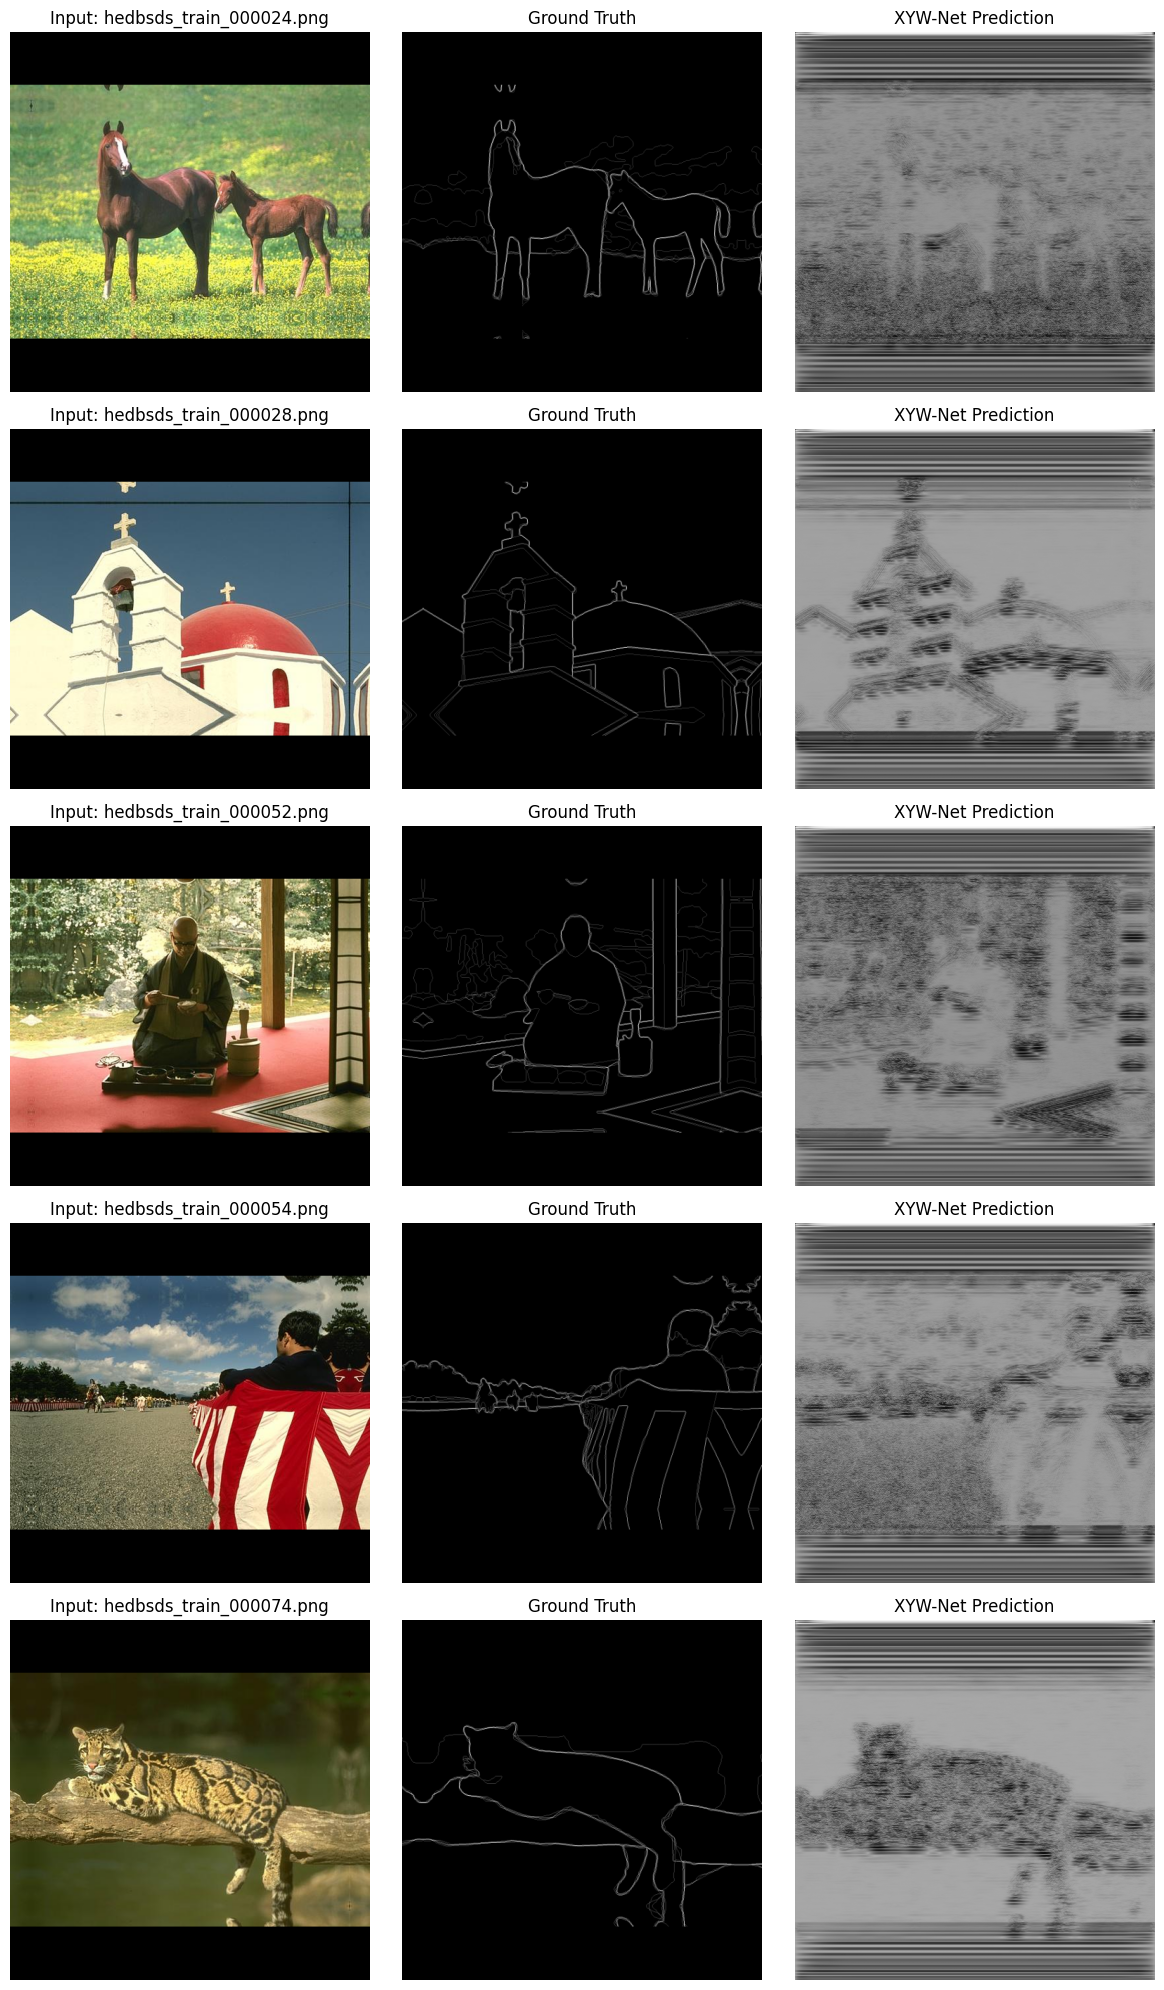


✓ Saved visualization to ..\bio DL\outputs\XYW-Net\xywnet_results.png


In [19]:
# ===== Visualize Results =====
num_viz = min(5, len(predictions))
fig, axes = plt.subplots(num_viz, 3, figsize=(12, 4*num_viz))
if num_viz == 1:
    axes = axes.reshape(1, -1)

for i in range(num_viz):
    # Original image
    img_path = DATASET_ROOT / 'test' / 'images' / image_names[i]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Ground truth
    gt = ground_truths[i]
    
    # Prediction
    pred = predictions[i]
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Input: {image_names[i]}')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(gt, cmap='gray')
    axes[i, 1].set_title('Ground Truth')
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(pred, cmap='gray')
    axes[i, 2].set_title(f'XYW-Net Prediction')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'xywnet_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved visualization to {OUTPUT_DIR / 'xywnet_results.png'}")

In [20]:
# ===== Save Results =====
import json

# Convert numpy types to native Python types for JSON serialization
metrics_json = {
    'ODS': float(metrics['ODS']),
    'ODS_thresh': float(metrics['ODS_thresh']),
    'OIS': float(metrics['OIS']),
    'AP': float(metrics['AP'])
}

results = {
    'model': 'XYW-Net',
    'paper': 'Parallel pathways with X, Y, and W cells',
    'bio_inspired': True,
    'bio': 'Retinal X, Y, W cell pathways',
    'improvement': 'Precision and computational efficiency',
    'metrics': metrics_json,
    'num_test_images': len(predictions),
    'device': str(DEVICE)
}

with open(OUTPUT_DIR / 'xywnet_metrics.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"✓ Saved metrics to {OUTPUT_DIR / 'xywnet_metrics.json'}")
print("\n✅ XYW-Net evaluation complete!")

✓ Saved metrics to ..\bio DL\outputs\XYW-Net\xywnet_metrics.json

✅ XYW-Net evaluation complete!
